# WildScan – Plants Species CNN
Classifies plant images into species within the 4 most common classes.
Final stage in the WildScan plant pipeline: CNN1 → Phylum → Class → **Species**

## 1. Setup

In [1]:
import os, shutil, time, random
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
from io import BytesIO

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report, confusion_matrix

ImageFile.LOAD_TRUNCATED_IMAGES = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Find Top 4 Species per Class & Download Images

In [ ]:
# iNaturalist taxon IDs for the 4 plant classes
CLASS_TAXONS = {
    'Liliopsida':     47163,   # corrected
    'Magnoliopsida':  47124,   # corrected
    'Pinopsida':      136329,
    'Polypodiopsida': 121943,
}

TARGET_PER_SPECIES = 300
TOP_N_SPECIES = 4  # top 4 species per class
SPECIES_DIR = './data/plants_species'

def get_top_species(class_taxon_id, n=4):
    r = requests.get(
        'https://api.inaturalist.org/v1/observations/species_counts',
        params={
            'taxon_id': class_taxon_id,
            'quality_grade': 'research',
            'rank': 'species',
            'per_page': n,
        },
        timeout=10
    ).json()
    return [(t['taxon']['id'], t['taxon']['name']) for t in r.get('results', [])]


def download_species(taxon_id, species_name, target):
    folder = os.path.join(SPECIES_DIR, species_name.replace(' ', '_'))
    os.makedirs(folder, exist_ok=True)
    current = len(os.listdir(folder))
    needed = target - current
    if needed <= 0:
        print(f'  {species_name}: already has {current}, skipping')
        return
    print(f'  {species_name}: fetching {needed} images...')
    fetched, page = 0, 1
    while fetched < needed and page <= 100:
        try:
            response = requests.get(
                'https://api.inaturalist.org/v1/observations',
                params={'taxon_id': taxon_id, 'quality_grade': 'research',
                        'photos': True, 'per_page': 100, 'page': page, 'order_by': 'id'},
                timeout=10
            )
            if response.status_code == 429:
                time.sleep(60)
                continue
            for obs in response.json().get('results', []):
                if fetched >= needed:
                    break
                try:
                    photo_url = obs['photos'][0]['url'].replace('square', 'medium')
                    img_data = requests.get(photo_url, timeout=10).content
                    img = Image.open(BytesIO(img_data)).convert('RGB')
                    count = len(os.listdir(folder))
                    img.save(os.path.join(folder, f'{count:05d}.jpg'))
                    fetched += 1
                except Exception:
                    continue
            page += 1
            time.sleep(1)
        except Exception:
            time.sleep(5)
            page += 1
    print(f'    Done! {species_name} now has {len(os.listdir(folder))} images')


# Download top 4 species for each class
for class_name, class_taxon_id in CLASS_TAXONS.items():
    print(f'\n--- {class_name} ---')
    top_species = get_top_species(class_taxon_id, TOP_N_SPECIES)
    print(f'Top species: {[s[1] for s in top_species]}')
    for taxon_id, species_name in top_species:
        download_species(taxon_id, species_name, TARGET_PER_SPECIES)
    time.sleep(1)

print('\nFinal counts:')
for cls in sorted(os.listdir(SPECIES_DIR)):
    print(f'  {cls}: {len(os.listdir(os.path.join(SPECIES_DIR, cls)))} images')


--- Liliopsida ---
Top species: ['Phragmites australis', 'Arisaema triphyllum', 'Dactylis glomerata', 'Maianthemum racemosum']
  Phragmites australis: fetching 300 images...
    Done! Phragmites australis now has 300 images
  Arisaema triphyllum: fetching 300 images...
    Done! Arisaema triphyllum now has 300 images
  Dactylis glomerata: fetching 300 images...
    Done! Dactylis glomerata now has 300 images
  Maianthemum racemosum: fetching 300 images...
    Done! Maianthemum racemosum now has 300 images

--- Magnoliopsida ---
Top species: ['Achillea millefolium', 'Trifolium repens', 'Alliaria petiolata', 'Trifolium pratense']
  Achillea millefolium: fetching 300 images...
    Done! Achillea millefolium now has 300 images
  Trifolium repens: fetching 300 images...
    Done! Trifolium repens now has 300 images
  Alliaria petiolata: fetching 300 images...
    Done! Alliaria petiolata now has 300 images
  Trifolium pratense: fetching 300 images...
    Done! Trifolium pratense now has 30

## 4. Save Data to Drive

In [ ]:
if not os.path.exists('/content/drive/MyDrive/plants_species'):
    shutil.copytree(SPECIES_DIR, '/content/drive/MyDrive/plants_species')
    print('Saved to Drive!')
else:
    print('Already exists in Drive, skipping.')

## 5. EDA

In [ ]:
classes = sorted(os.listdir(SPECIES_DIR))
class_counts = {cls: len(os.listdir(os.path.join(SPECIES_DIR, cls))) for cls in classes}

plt.figure(figsize=(16, 5))
plt.bar(class_counts.keys(), class_counts.values(), color='forestgreen')
plt.title('Images per Plant Species')
plt.xlabel('Species')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(f'Total classes: {len(classes)}')
print(f'Total images: {sum(class_counts.values())}')

## 6. Preprocessing & DataLoaders

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

full_dataset = ImageFolder(root=SPECIES_DIR, transform=None)
class_to_idx = full_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}
NUM_CLASSES = len(class_to_idx)
print('Classes:', class_to_idx)
print(f'Total samples: {len(full_dataset)}')

total = len(full_dataset)
train_size = int(0.90 * total)
val_size   = int(0.05 * total)
test_size  = total - train_size - val_size

train_data, val_data, test_data = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)
print(f'Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}')

In [ ]:
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

BATCH_SIZE = 32
train_loader = DataLoader(TransformSubset(train_data, train_transforms),   batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(TransformSubset(val_data,   val_test_transforms), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(TransformSubset(test_data,  val_test_transforms), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print('DataLoaders ready!')

## 7. Model – Fine-Tuned ResNet-18

In [ ]:
model = models.resnet18(weights='IMAGENET1K_V1')

for param in model.parameters():
    param.requires_grad = True

model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)

print(f'Model ready! Classes: {NUM_CLASSES}')
print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

## 8. Training

In [12]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total


NUM_EPOCHS = 20
train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_val_acc = 0
best_model_path = 'best_plants_species_model.pth'

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss,   val_acc   = eval_epoch(model,  val_loader,   criterion)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    print(f'Epoch {epoch+1:02d}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

print(f'\nBest Val Accuracy: {best_val_acc:.4f}')

Epoch 01/20 | Train Loss: 1.3727 Acc: 0.5872 | Val Loss: 0.8725 Acc: 0.7292
Epoch 02/20 | Train Loss: 0.6145 Acc: 0.8071 | Val Loss: 0.6613 Acc: 0.8125
Epoch 03/20 | Train Loss: 0.4096 Acc: 0.8719 | Val Loss: 0.5935 Acc: 0.8208
Epoch 04/20 | Train Loss: 0.2908 Acc: 0.9146 | Val Loss: 0.6693 Acc: 0.8208
Epoch 05/20 | Train Loss: 0.2121 Acc: 0.9372 | Val Loss: 0.6217 Acc: 0.8250
Epoch 06/20 | Train Loss: 0.1625 Acc: 0.9562 | Val Loss: 0.6503 Acc: 0.8417
Epoch 07/20 | Train Loss: 0.1297 Acc: 0.9642 | Val Loss: 0.7075 Acc: 0.8167
Epoch 08/20 | Train Loss: 0.0941 Acc: 0.9744 | Val Loss: 0.5681 Acc: 0.8458
Epoch 09/20 | Train Loss: 0.0729 Acc: 0.9818 | Val Loss: 0.5693 Acc: 0.8542
Epoch 10/20 | Train Loss: 0.0579 Acc: 0.9896 | Val Loss: 0.5845 Acc: 0.8458
Epoch 11/20 | Train Loss: 0.0523 Acc: 0.9901 | Val Loss: 0.5723 Acc: 0.8583
Epoch 12/20 | Train Loss: 0.0473 Acc: 0.9922 | Val Loss: 0.5485 Acc: 0.8583
Epoch 13/20 | Train Loss: 0.0508 Acc: 0.9896 | Val Loss: 0.5793 Acc: 0.8583
Epoch 14/20 

## 9. Results

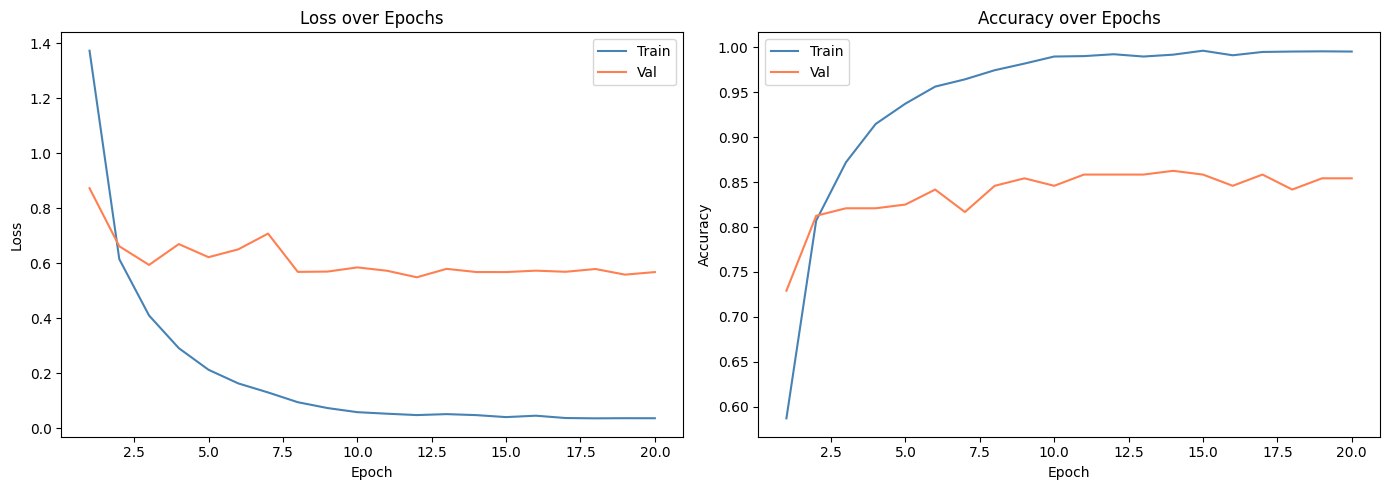

In [13]:
epochs = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, train_losses, label='Train', color='steelblue')
ax1.plot(epochs, val_losses,   label='Val',   color='coral')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs, train_accs, label='Train', color='steelblue')
ax2.plot(epochs, val_accs,   label='Val',   color='coral')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

In [16]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        outputs = model(imgs.to(device))
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

cm = confusion_matrix(all_labels, all_preds)
tp = np.diag(cm)
fp = cm.sum(axis=0) - tp
actual = cm.sum(axis=1)

print(f'General Accuracy: {(all_preds == all_labels).mean():.4f} ({(all_preds == all_labels).mean()*100:.2f}%)')
print()
print(f'{"Class":<30} {"TP":>6} {"FP":>6} {"Actual":>8} {"Precision":>10}')
print('-' * 65)
for i in range(len(cm)):
    precision = tp[i] / (tp[i] + fp[i]) if (tp[i] + fp[i]) > 0 else 0
    print(f'{class_names[i]:<30} {tp[i]:>6} {fp[i]:>6} {actual[i]:>8} {precision:>10.4f}')

General Accuracy: 0.8595 (85.95%)

Class                              TP     FP   Actual  Precision
-----------------------------------------------------------------
Achillea_millefolium                7      1       11     0.8750
Alliaria_petiolata                 12      0       12     1.0000
Arisaema_triphyllum                16      1       17     0.9412
Dactylis_glomerata                 18      2       20     0.9000
Equisetum_arvense                  16      3       18     0.8421
Haddowia_longipes                  10      2       11     0.8333
Juniperus_virginiana               17      0       17     1.0000
Maianthemum_racemosum              12      0       14     1.0000
Onoclea_sensibilis                 11      5       12     0.6875
Phragmites_australis               20      3       23     0.8696
Pinus_strobus                       9      4       13     0.6923
Pinus_sylvestris                    8      3        8     0.7273
Polystichum_acrostichoides         12      1       19 

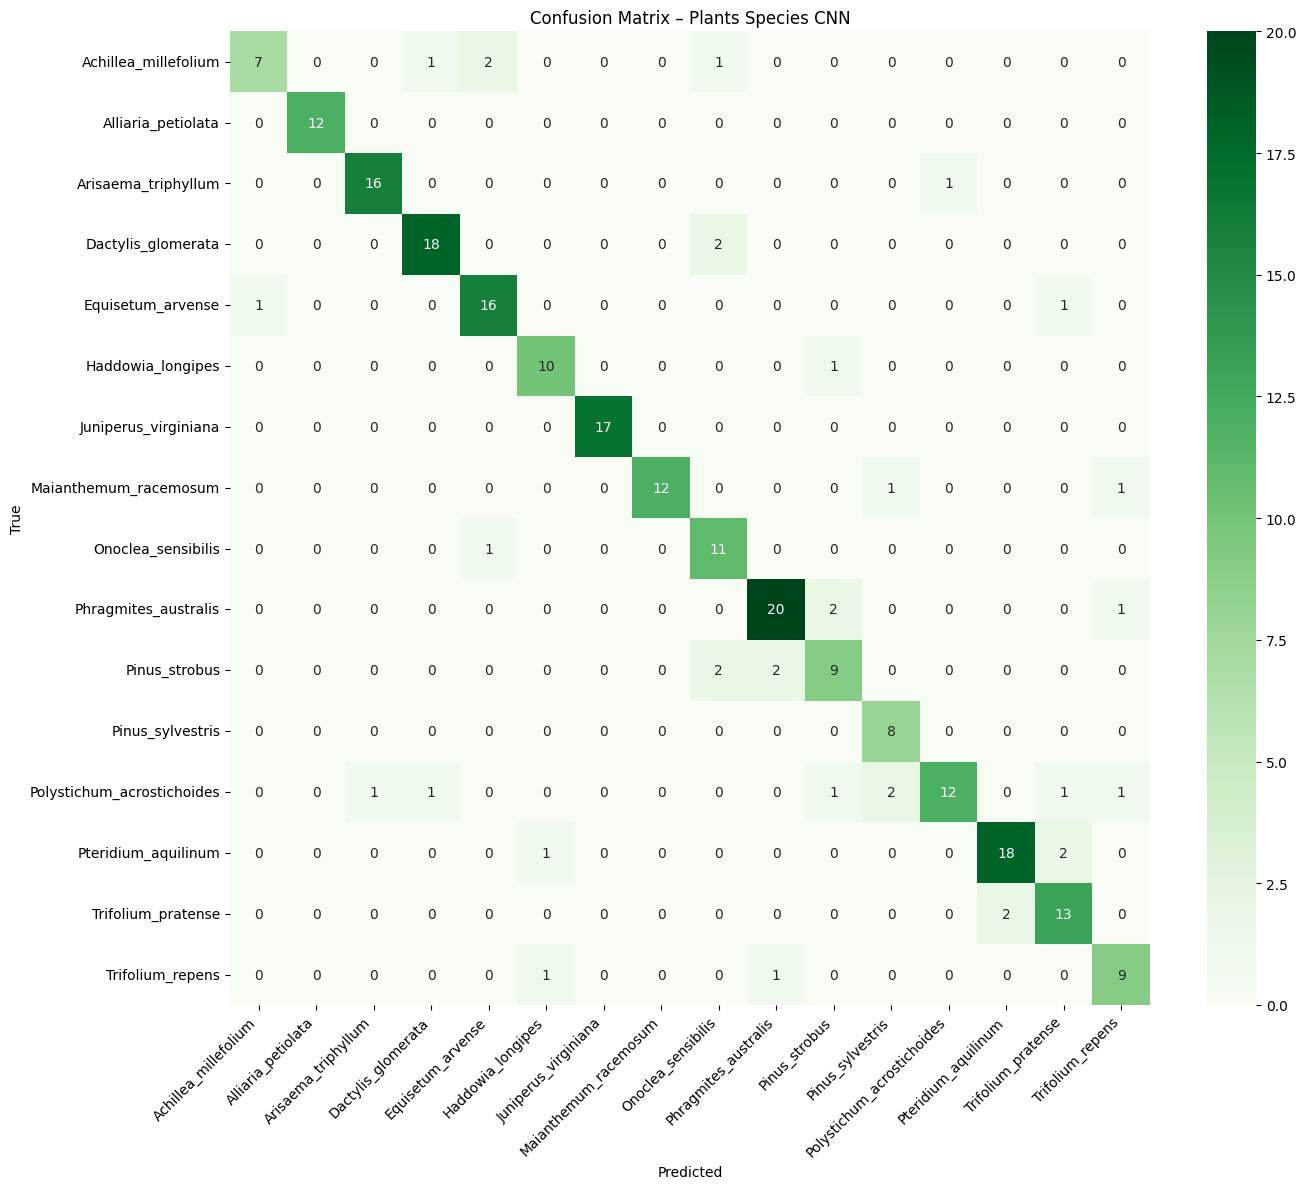

                            precision    recall  f1-score   support

      Achillea_millefolium       0.88      0.64      0.74        11
        Alliaria_petiolata       1.00      1.00      1.00        12
       Arisaema_triphyllum       0.94      0.94      0.94        17
        Dactylis_glomerata       0.90      0.90      0.90        20
         Equisetum_arvense       0.84      0.89      0.86        18
         Haddowia_longipes       0.83      0.91      0.87        11
      Juniperus_virginiana       1.00      1.00      1.00        17
     Maianthemum_racemosum       1.00      0.86      0.92        14
        Onoclea_sensibilis       0.69      0.92      0.79        12
      Phragmites_australis       0.87      0.87      0.87        23
             Pinus_strobus       0.69      0.69      0.69        13
          Pinus_sylvestris       0.73      1.00      0.84         8
Polystichum_acrostichoides       0.92      0.63      0.75        19
       Pteridium_aquilinum       0.90      0.86

In [18]:
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names[:len(cm)],
            yticklabels=class_names[:len(cm)], cmap='Greens')
plt.title('Confusion Matrix – Plants Species CNN')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names[:len(cm)]))

## 10. Save to Drive

In [19]:
shutil.copy(best_model_path, '/content/drive/MyDrive/best_plants_species_model.pth')
print('Model saved to Drive!')

Model saved to Drive!
